# EDA completo — Projeto Semantix / EBAC

**Tema:** Redução de acidentes graves e fatais em rodovias federais brasileiras com apoio de análise de dados.

Este notebook foi preparado para ler os arquivos `datatran2022.csv`, `datatran2023.csv` e `datatran2024.csv` na pasta `data/raw/`, consolidar a base e gerar uma EDA inicial.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1) Descobrir os caminhos do projeto

In [2]:
cwd = Path.cwd()

if (cwd / "data" / "raw").exists():
    BASE_DIR = cwd
elif (cwd.parent / "data" / "raw").exists():
    BASE_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "Não encontrei a pasta data/raw. Abra a raiz do projeto ou execute este notebook dentro da pasta notebooks/."
    )

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
EXPORTS_DIR = BASE_DIR / "exports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RAW_DIR:", RAW_DIR)

BASE_DIR: c:\Users\uceje\Downloads\Nova pasta\semantix_projeto_starter
RAW_DIR: c:\Users\uceje\Downloads\Nova pasta\semantix_projeto_starter\data\raw


## 2) Encontrar e ler os arquivos `datatran`

In [3]:
arquivos = sorted(RAW_DIR.glob("datatran20*.csv"))

if not arquivos:
    raise FileNotFoundError("Nenhum arquivo datatran20*.csv encontrado em data/raw.")

print("Arquivos encontrados:")
for a in arquivos:
    print("-", a.name)

dfs = []
for arq in arquivos:
    df_temp = pd.read_csv(arq, sep=";", encoding="latin1", low_memory=False)
    df_temp["arquivo_origem"] = arq.name
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
df.columns = [c.strip().lower() for c in df.columns]

print("\nShape consolidado:", df.shape)
df.head()

Arquivos encontrados:
- datatran2022.csv
- datatran2023.csv
- datatran2024.csv

Shape consolidado: (205528, 31)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,arquivo_origem
0,405151.0,2022-01-01,sábado,01:35:00,PI,316,415,MARCOLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,1,1,1,3,"-7,43280012","-40,68261908",SPRF-PI,DEL04-PI,UOP03-DEL04-PI,datatran2022.csv
1,405158.0,2022-01-01,sábado,02:40:00,PR,116,33,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,...,0,1,1,2,"-25,114403","-48,8467554",SPRF-PR,DEL01-PR,UOP02-DEL01-PR,datatran2022.csv
2,405172.0,2022-01-01,sábado,05:22:00,MS,163,393,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,...,1,1,1,3,"-21,228445","-54,456296",SPRF-MS,DEL02-MS,UOP01-DEL02-MS,datatran2022.csv
3,405203.0,2022-01-01,sábado,07:00:00,RJ,101,457,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,...,1,0,1,2,"-23,03149804","-44,17715297",SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ,datatran2022.csv
4,405207.0,2022-01-01,sábado,09:00:00,MG,40,"508,3",RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,...,3,0,0,1,"-19,76061249","-44,1347544",SPRF-MG,DEL02-MG,UOP01-DEL02-MG,datatran2022.csv


## 3) Tratamento inicial

In [4]:
rename_map = {
    "condicao_metereologica": "condicao_meteorologica",
}
df = df.rename(columns=rename_map)

df["data_inversa"] = pd.to_datetime(df["data_inversa"], format="%Y-%m-%d", errors="coerce")
df["horario"] = pd.to_datetime(df["horario"], format="%H:%M:%S", errors="coerce")

df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["ano_mes"] = df["data_inversa"].dt.to_period("M").astype(str)
df["dia"] = df["data_inversa"].dt.day
df["hora"] = df["horario"].dt.hour

def faixa_horaria(h):
    if pd.isna(h):
        return "Não informado"
    h = int(h)
    if 0 <= h < 6:
        return "00-05"
    elif 6 <= h < 12:
        return "06-11"
    elif 12 <= h < 18:
        return "12-17"
    else:
        return "18-23"

df["faixa_horaria"] = df["hora"].apply(faixa_horaria)

numericas = [
    "br", "km", "pessoas", "mortos", "feridos_leves", "feridos_graves",
    "ilesos", "ignorados", "feridos", "veiculos"
]
for col in numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["acidente_fatal"] = np.where(df["mortos"].fillna(0) > 0, 1, 0)
df["acidente_com_ferido_grave"] = np.where(df["feridos_graves"].fillna(0) > 0, 1, 0)

df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,uop,arquivo_origem,ano,mes,ano_mes,dia,hora,faixa_horaria,acidente_fatal,acidente_com_ferido_grave
0,405151.0,2022-01-01,sábado,1900-01-01 01:35:00,PI,316,415.0,MARCOLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,UOP03-DEL04-PI,datatran2022.csv,2022,1,2022-01,1,1,00-05,0,0
1,405158.0,2022-01-01,sábado,1900-01-01 02:40:00,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,...,UOP02-DEL01-PR,datatran2022.csv,2022,1,2022-01,1,2,00-05,1,0
2,405172.0,2022-01-01,sábado,1900-01-01 05:22:00,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,...,UOP01-DEL02-MS,datatran2022.csv,2022,1,2022-01,1,5,00-05,0,0
3,405203.0,2022-01-01,sábado,1900-01-01 07:00:00,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,...,UOP03-DEL03-RJ,datatran2022.csv,2022,1,2022-01,1,7,06-11,0,1
4,405207.0,2022-01-01,sábado,1900-01-01 09:00:00,MG,40,NaN,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,...,UOP01-DEL02-MG,datatran2022.csv,2022,1,2022-01,1,9,06-11,0,0


## 4) Auditoria inicial

In [5]:
print("Linhas e colunas:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados (primeiros 20):")
print(df.dtypes.head(20))

print("\nNulos (% top 15):")
(df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2)

Linhas e colunas: (205528, 39)

Colunas:
['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_meteorologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'arquivo_origem', 'ano', 'mes', 'ano_mes', 'dia', 'hora', 'faixa_horaria', 'acidente_fatal', 'acidente_com_ferido_grave']

Tipos de dados (primeiros 20):
id                               float64
data_inversa              datetime64[ns]
dia_semana                        object
horario                   datetime64[ns]
uf                                object
br                                 int64
km                               float64
municipio                         object
causa_acidente                    object
tipo_acidente                     object
cl

km                        37.76
uop                        0.10
delegacia                  0.04
regional                   0.01
classificacao_acidente     0.00
data_inversa               0.00
id                         0.00
br                         0.00
uf                         0.00
horario                    0.00
dia_semana                 0.00
fase_dia                   0.00
municipio                  0.00
causa_acidente             0.00
tipo_acidente              0.00
dtype: float64

## 5) Tabelas resumo

In [6]:
def salva_csv(dataframe, nome):
    caminho = EXPORTS_DIR / nome
    dataframe.to_csv(caminho, index=False, encoding="utf-8-sig")
    print("Exportado:", caminho.name)

resumo_ano = (
    df.groupby("ano", dropna=False)
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos_graves=("feridos_graves", "sum"),
          feridos=("feridos", "sum"),
          veiculos=("veiculos", "sum")
      )
      .reset_index()
      .sort_values("ano")
)
resumo_ano

,ano,acidentes,mortos,feridos_graves,feridos,veiculos
0,2022,64606,5441,18173,73065,127732
1,2023,67766,5627,18958,78463,135384
2,2024,73156,6160,20344,84526,145274


In [9]:
salva_csv(resumo_ano, "resumo_por_ano.csv")

resumo_uf = (
    df.groupby("uf", dropna=False)
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos_graves=("feridos_graves", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)
salva_csv(resumo_uf, "resumo_por_uf.csv")
resumo_uf.head(10)

Exportado: resumo_por_ano.csv
Exportado: resumo_por_uf.csv


,uf,acidentes,mortos,feridos_graves
10,MG,26598,2221,8079
23,SC,23773,1130,5998
17,PR,22079,1739,5832
18,RJ,16672,908,3332
22,RS,15073,976,3366
25,SP,14022,682,2392
4,BA,11355,1712,3856
8,GO,9553,878,2665
15,PE,8980,895,3106
12,MT,7050,778,1887


In [10]:
resumo_causa = (
    df.groupby("causa_acidente", dropna=False)
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos_graves=("feridos_graves", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)
salva_csv(resumo_causa, "resumo_por_causa.csv")
resumo_causa.head(10)

Exportado: resumo_por_causa.csv


,causa_acidente,acidentes,mortos,feridos_graves
57,Reação tardia ou ineficiente do condutor,29193,1812,7081
8,Ausência de reação do condutor,27546,1946,6984
0,Acessar a via sem observar a presença dos outr...,18873,1146,6386
74,Velocidade Incompatível,13590,1424,4387
14,Condutor deixou de manter distância do veículo...,13068,269,2458
39,Ingestão de álcool pelo condutor,11803,573,2656
41,Manobra de mudança de faixa,11707,705,2910
23,Demais falhas mecânicas ou elétricas,9015,190,1174
69,Transitar na contramão,6889,2566,3857
13,Condutor Dormindo,6395,625,1826


In [11]:
resumo_classificacao = (
    df.groupby("classificacao_acidente", dropna=False)
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos_graves=("feridos_graves", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)
salva_csv(resumo_classificacao, "resumo_por_classificacao.csv")
resumo_classificacao

Exportado: resumo_por_classificacao.csv


,classificacao_acidente,acidentes,mortos,feridos_graves
1,Com Vítimas Feridas,156533,0,51875
2,Sem Vítimas,34248,0,0
0,Com Vítimas Fatais,14744,17228,5598
3,NaN,3,0,2


In [12]:
resumo_faixa_horaria = (
    df.groupby("faixa_horaria", dropna=False)
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos_graves=("feridos_graves", "sum")
      )
      .reset_index()
)
salva_csv(resumo_faixa_horaria, "resumo_por_faixa_horaria.csv")
resumo_faixa_horaria

Exportado: resumo_por_faixa_horaria.csv


,faixa_horaria,acidentes,mortos,feridos_graves
0,00-05,26337,3408,7595
1,06-11,58090,3508,14586
2,12-17,62428,4007,17131
3,18-23,58673,6305,18163


## 6) Salvar base tratada

In [13]:
saida_base = PROCESSED_DIR / "acidentes_prf_2022_2024_tratado.csv"
df.to_csv(saida_base, index=False, encoding="utf-8-sig")
print("Base tratada salva em:", saida_base)

Base tratada salva em: c:\Users\uceje\Downloads\Nova pasta\semantix_projeto_starter\data\processed\acidentes_prf_2022_2024_tratado.csv


## 7) Gráficos rápidos

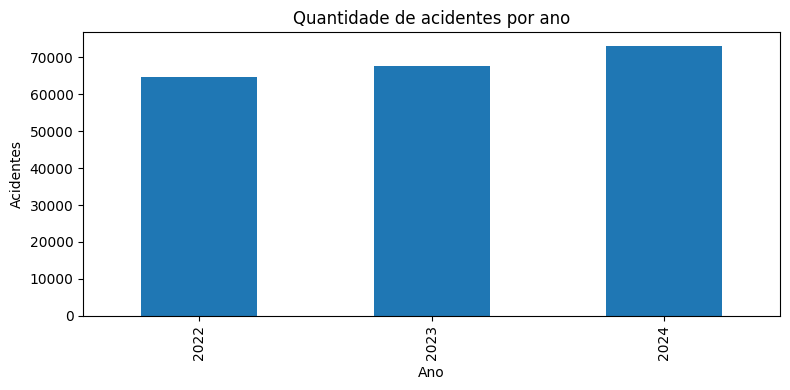

In [8]:
plt.style.use("default")

plt.figure(figsize=(8,4))
df.groupby("ano")["id"].count().plot(kind="bar")
plt.title("Quantidade de acidentes por ano")
plt.xlabel("Ano")
plt.ylabel("Acidentes")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,4))
df.groupby("uf")["id"].count().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 UFs com mais acidentes")
plt.xlabel("UF")
plt.ylabel("Acidentes")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
df.groupby("causa_acidente")["id"].count().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 causas de acidente")
plt.xlabel("Causa")
plt.ylabel("Acidentes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,4))
df.groupby("ano_mes")["id"].count().plot()
plt.title("Evolução mensal da quantidade de acidentes")
plt.xlabel("Ano-Mês")
plt.ylabel("Acidentes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Próximo passo
Depois de rodar tudo, você já terá:
- base consolidada em `data/processed/`
- tabelas resumo em `exports/`
- insumos reais para preencher os documentos e montar o Looker Studio
